In [ ]:
# Old custom version look at the next cell!
# # Cell 1: Imports

# import numpy as np
# from surrogates_interface.transformers import Transformer
# from tensorflow_surrogates import TensorflowSurrogate
# import matplotlib.pyplot as plt
# import os
# from surrogates_interface.surrogates import TensorFlowModel

# def predict_loads_for_turbine(surrogates, wsp_sectors, ti_sectors, yaw, power_demand):
#     """
#     Predicts all loads for a turbine given ambient and control conditions.

#     Parameters
#     ----------
#     surrogates : dict
#         Dictionary of loaded TensorflowSurrogate models keyed by channel.
#     wsp_sectors : list or array of 4 floats
#         Sector-averaged wind speeds [u, r, d, l].
#     ti_sectors : list or array of 4 floats
#         Sector-averaged turbulence intensities [u, r, d, l].
#     yaw : float
#         Yaw angle in degrees.
#     power_demand : float
#         Power setpoint in kW or per unit (depends on training).

#     Returns
#     -------
#     dict
#         Predicted loads per channel.
#     """
#     x = np.array(wsp_sectors + ti_sectors + [yaw, power_demand]).reshape(1, -1)
#     predictions = {}
#     for ch, surrogate in surrogates.items():
#         predictions[ch] = surrogate.predict(x).flatten()[0]
#     return predictions


# # Updated list of available surrogate channels based on files you have
# channels = [
#     "SA_blade_root_ip", "SA_blade_root_oop", "SA_shaft_oop", "SA_shaft_yaw",
#     "SA_tbss", "SA_tbfa", "SA_tower_top_fa", "SA_tower_top_ss"
# ]

# surrogates = {}
# for ch in channels:
#     model_path = os.path.join("models", f"{ch}.keras")
#     scaler_path = os.path.join("models", f"scaler_{ch}.h5")
#     surrogates[ch] = TensorflowSurrogate(model_path, scaler_path)


# # Cell: Example prediction


# #Example test
# wsp = [8., 8.0, 8.0, 8.0]
# ti = [12,12, 12, 12]
# yaw = 0.0
# power = 100.0

# loads = predict_loads_for_turbine(surrogates, wsp, ti, yaw, power)
# for k, v in loads.items():
#     print(f"{k}: {v:.3f}")


In [2]:
# Cell 1: Imports
import sys, os

# 1) where is this notebook running?
notebook_dir = os.getcwd()                # usually the "notebooks/" folder

# 2) compute the project root (one level up)
project_root = os.path.abspath(os.path.join(notebook_dir, os.pardir))

# 3) insert it once
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # 0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR
from surrogates_interface.transformers import Transformer
from tensorflow_surrogates import TensorflowSurrogate
import matplotlib.pyplot as plt
from surrogates_interface.surrogates import TensorFlowModel

# Updated list of available surrogate channels based on files you have
channels = [
    "SA_blade_root_ip", "SA_blade_root_oop","SA_blade_root_projected", "SA_shaft_oop", "SA_shaft_yaw",
    "SA_tbss", "SA_tbfa", "SA_tower_top_fa", "SA_tower_torsion","SA_tower_top_ss","SA_tower_base_projected"
]

surrogates = {}
for ch in channels:
    model_path = os.path.join("models", f"{ch}.keras")
    scaler_path = os.path.join("models", f"scaler_{ch}.h5")
    # surrogates[ch] = TensorFlowModel(model_path, scaler_path)
    surrogates[ch] = TensorFlowModel.load_h5(
    model_path=model_path, extra_data_path=scaler_path)

# Cell: Example prediction

#Example test
wsp = [10., 10.0, 10.0, 10.0]
ti = [12,12, 12, 12]
yaw = 0.0
power = 100.0

inputs= np.array([10,10,10,10,12,12,12,12,0,100], dtype=np.float64)
y_pred = {}
for ch, surrogate in surrogates.items():
    y_pred[ch] = surrogates[ch].predict_output(inputs.reshape(1, -1))

for k, v in y_pred.items():
    print(f"{k}: {v.item():.3f}")


SA_blade_root_ip: 4.635
SA_blade_root_oop: 3.475
SA_blade_root_projected: 4.699
SA_shaft_oop: 1.586
SA_shaft_yaw: 1.634
SA_tbss: 3.590
SA_tbfa: 13.410
SA_tower_top_fa: 1.641
SA_tower_torsion: 1.595
SA_tower_top_ss: 0.357
SA_tower_base_projected: 13.552


Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -30.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -29.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -28.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -27.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -26.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -25.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -24.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -23.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -22.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -21.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -20.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -19.  100. ]
Input vector: [  8.8   8.    7.6   8.   12.   12.   12.   12.  -18.  100. ]
Input vector

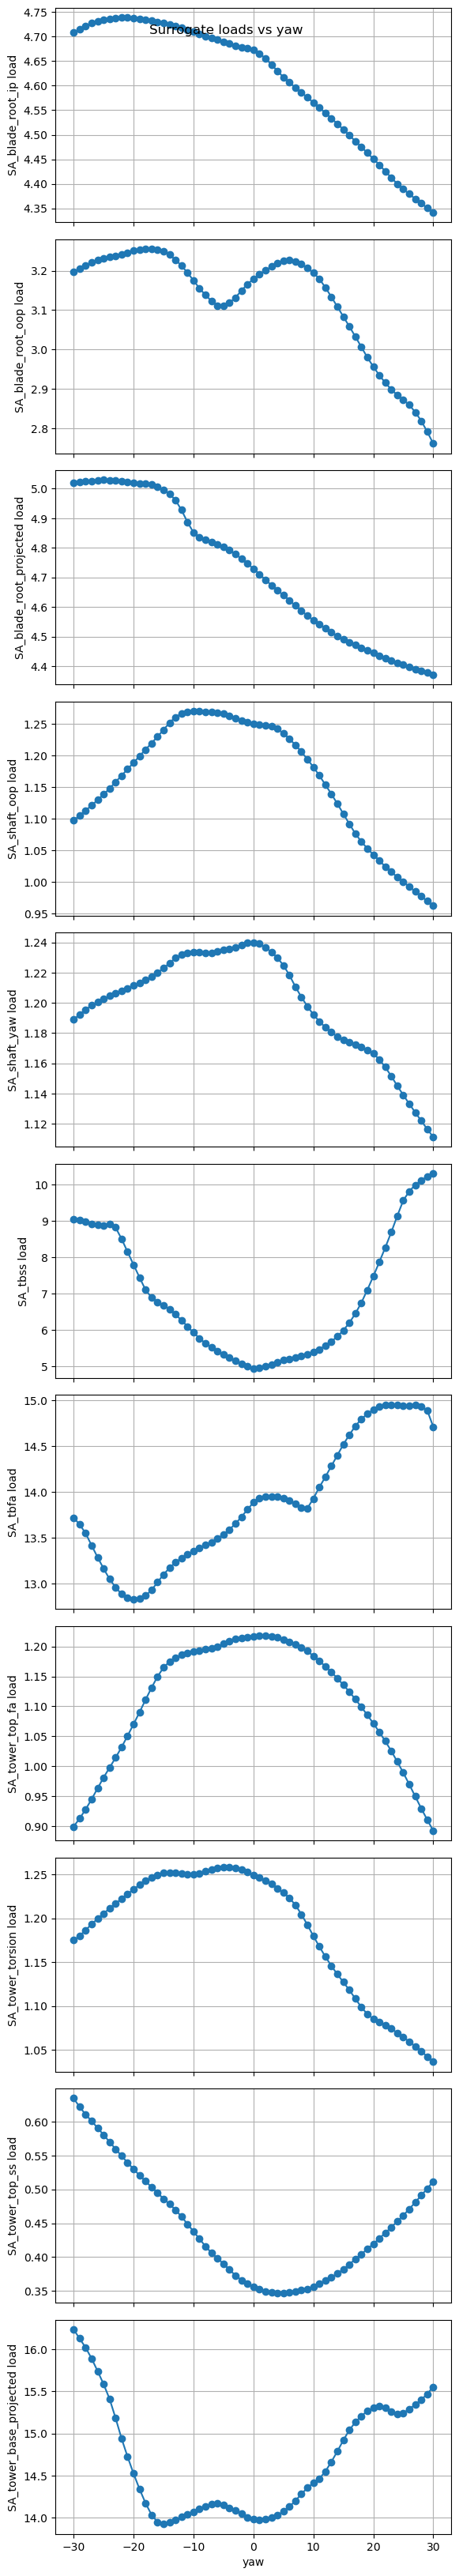

In [3]:
# Cell: Batch load prediction over varying wind conditions

import numpy as np
import matplotlib.pyplot as plt

# --- User input: define sweep scenario ---
# Vary wind speed from 4 to 12 m/s, keep TI, yaw, power constant
sweep_var = "yaw"
# wsp_range = np.arange(6.0, 12.0, 1.0)
wsp_range = np.array(8.0)
ti_range = np.array(12.0)  # in %
yaw_range =   np.arange(-30, 31, 1.0)   # degrees
power_range = np.array(100) # percentage of rated power

# --- Construct full input matrix for prediction ---
X_inputs = []
sweep_values = []

for wsp in (wsp_range if sweep_var == "wsp" else [wsp_range]):
    for ti in (ti_range if sweep_var == "ti" else [ti_range]):
        for yaw in (yaw_range if sweep_var == "yaw" else [yaw_range]):
            for power in (power_range if sweep_var == "power" else [power_range]):
                # Simulate 4 turbines, constant conditions for all
                input_vec = np.array(
                   #[wsp]*4 + [ti]*4 + [yaw, power], dtype=np.float32
                   [wsp*1.1]+ [wsp]+[wsp*0.95]+[wsp]+ [ti*1.0] + [ti*1.0] +[ti*1.0] +[ti*1] +[yaw, power], dtype=np.float32
                )
                print(f"Input vector: {input_vec}")
                X_inputs.append(input_vec)
                sweep_values.append(eval(sweep_var))  # value of the variable being swept

X_inputs = np.stack(X_inputs)  # shape (N, 10)

# --- Run predictions ---
Y_outputs = {ch: [] for ch in surrogates.keys()}

for x in X_inputs:
    for ch, model in surrogates.items():
        y = model.predict_output(x.reshape(1, -1)).item()
        Y_outputs[ch].append(y)

# --- Plot ---
fig, axs = plt.subplots(len(Y_outputs), 1, figsize=(6, 3*len(Y_outputs)), sharex=True)

for i, (ch, values) in enumerate(Y_outputs.items()):
    axs[i].plot(sweep_values, values, marker='o')
    axs[i].set_ylabel(f"{ch} load")
    axs[i].grid(True)

axs[-1].set_xlabel(sweep_var)
fig.suptitle(f"Surrogate loads vs {sweep_var}")
plt.tight_layout()
plt.show()


<xarray.Dataset> Size: 48B
Dimensions:  (wd: 2, ws: 1)
Coordinates:
  * wd       (wd) float64 16B 0.0 360.0
  * ws       (ws) int64 8B 12
Data variables:
    P        (wd) int64 16B 1 1
    TI       float64 8B 0.1
Attributes:
    sector_width:  360

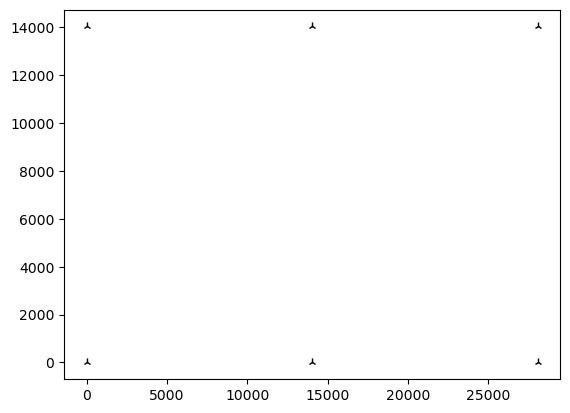

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
from py_wake.site import UniformSite
# from py_wake.wind_farm_models.engineering_models import PropagateDownwind
from py_wake.examples.data.hornsrev1 import V80
from dependencies import compute_sector_average, PropagateDownwindNoSelfInduction, predict_loads_sector_average
from abc import ABC
from py_wake.deficit_models import ZongGaussianDeficit, NOJDeficit
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.flow_map import HorizontalGrid
from py_wake.site._site import UniformSite
from py_wake.site.shear import PowerShear
from py_wake.turbulence_models import CrespoHernandez, GCLTurbulence,STF2017TurbulenceModel
# from py_wake.deficit_models.gaussian import GaussianDeficit
from py_wake.site import UniformSite
from py_wake.examples.data.hornsrev1 import V80, Hornsrev1Site
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Hides INFO and WARNING messages
import tensorflow as tf
tf.get_logger().setLevel('ERROR')         # Hides tf.function retracing warnings
from iea3_4_pywake_openfast_1 import iea3_4
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake.wind_turbines import WindTurbine, WindTurbines


wt = iea3_4
u = [0,3,12,25,30]
ct = [0,0,0,0, 0]
power = [0,0,0,0,0]

wt2 = WindTurbine(name='MyWT',
                    diameter=iea3_4.diameter(),
                    hub_height=iea3_4.hub_height(),
                    powerCtFunction=PowerCtTabular(u,power,'kW',ct))
wts = WindTurbines.from_WindTurbine_lst([wt2, wt])
# Wind farm layout
D = wt.diameter()
x = np.array([0, 6, 12, 0, 6, 12]) *18* D
y = np.array([0, 0, 0, 6, 6, 6]) *18* D

# Site and turbine


site = UniformSite(shear=PowerShear(h_ref=wt.hub_height(), alpha=0.2))
# site = Hornsrev1Site()


# Wind farm model (no self induction)
wfm = PropagateDownwindNoSelfInduction(
    site,
    wts,
    wake_deficitModel=ZongGaussianDeficit(),
    # wake_deficitModel=NOJDeficit(),
    turbulenceModel=CrespoHernandez(),
    # turbulenceModel=GCLTurbulence(),
    deflectionModel=JimenezWakeDeflection(),   
)

# Dummy yaw and power inputs
yaw_angles = np.array([0, 0, 0, 0, 0, 0])  # degrees
# power_levels = np.array([60, 100, 100, 60, 100, 100])  # in kW
power_levels = np.array([100, 100, 100, 100, 100, 100])  # in kW
tilt_angles = np.zeros_like(yaw_angles)  # All turbines have 0 tilt

# Sanity checks
# wts.ct(ws=8, type=0,power_demand=100)
plt.plot(x,y,'2k')
site.ds


In [6]:
sim_res = wfm(
    x=x,
    y=y,
    type=[True, True, True, True, True, True],  # Only first three turbines are active
    TI=[0.10],            # single turbulence intensity
    wd=[180],              # single wind direction
    ws=[8.0],              # single wind speed
    yaw=yaw_angles,        # array of 6 values
    tilt=tilt_angles,      # array of 6 values
    power_demand=power_levels,     # array of 6 values
)


sa = compute_sector_average(sim_res, look="downwind")
print(sa.loc[{'quantity':'TI_eff'}])
# Predict loads using sector-averaged inflow
loads = predict_loads_sector_average(
    surrogates,   # dictionary of TensorflowSurrogate objects
    sim_res,      # simulation result from PyWake
    sa,           # sector-averaged inflow (the variable `sa`)
    yaw_angles,   # additional input 1: yaw
    power_levels  # additional input 2: power demand
)



# Visualize or inspect loads
# print(loads)


<xarray.DataArray (wt: 6, wd: 1, ws: 1, direction: 4)> Size: 96B
array([[[[0.10000002, 0.10000002, 0.10000002, 0.10000002]]],


       [[[0.10000002, 0.10000002, 0.10000002, 0.10000002]]],


       [[[0.10000002, 0.10000002, 0.10000002, 0.10000002]]],


       [[[0.11785674, 0.11785674, 0.11785673, 0.11785674]]],


       [[[0.11785674, 0.11785674, 0.11785673, 0.11785674]]],


       [[[0.11785674, 0.11785674, 0.11785673, 0.11785674]]]],
      dtype=float32)
Coordinates:
  * wt         (wt) int64 48B 0 1 2 3 4 5
  * wd         (wd) int64 8B 180
  * ws         (ws) float64 8B 8.0
    quantity   <U6 24B 'TI_eff'
  * direction  (direction) <U5 80B 'up' 'right' 'down' 'left'


In [7]:
sim_res

<xarray.SimulationResult> Size: 648B
Dimensions:       (wt: 6, wd: 1, ws: 1)
Coordinates:
  * wt            (wt) int64 48B 0 1 2 3 4 5
  * wd            (wd) int64 8B 180
  * ws            (ws) float64 8B 8.0
    type          (wt) int64 48B 1 1 1 1 1 1
Data variables: (12/17)
    WS_eff        (wt, wd, ws) float64 48B 8.0 8.0 8.0 7.982 7.982 7.982
    TI_eff        (wt, wd, ws) float64 48B 0.1 0.1 0.1 0.1179 0.1179 0.1179
    Power         (wt, wd, ws) float64 48B 1.872e+06 1.872e+06 ... 1.86e+06
    CT            (wt, wd, ws) float64 48B 0.8164 0.8164 ... 0.8164 0.8164
    yaw           (wt) int64 48B 0 0 0 0 0 0
    tilt          (wt) int64 48B 0 0 0 0 0 0
    ...            ...
    TI            float64 8B 0.1
    wd_bin_size   float64 8B 360.0
    WS            float64 8B 8.0
    ws_l          float64 8B 7.5
    ws_u          float64 8B 8.5
    P             float64 8B 1.0

In [8]:
# print(loads.coords)
# print(loads.coords["name"].values)

df = pd.DataFrame(
    loads.squeeze(["wd", "ws"]).values,  # shape (6, 8)
    columns=loads.coords["name"].values,
    index=[f"T{i}" for i in range(loads.sizes["wt"])]
)

print(df)


    SA_blade_root_ip  SA_blade_root_oop  SA_blade_root_projected  \
T0          4.590321           2.650101                 4.646989   
T1          4.590321           2.650101                 4.646989   
T2          4.590321           2.650101                 4.646989   
T3          4.600754           2.976680                 4.706464   
T4          4.600754           2.976680                 4.706464   
T5          4.600754           2.976680                 4.706464   

    SA_shaft_oop  SA_shaft_yaw   SA_tbss    SA_tbfa  SA_tower_top_fa  \
T0      0.980320      1.086853  4.240963  12.787837         0.965823   
T1      0.980320      1.086853  4.240963  12.787837         0.965823   
T2      0.980320      1.086853  4.240963  12.787837         0.965823   
T3      1.156075      1.273220  5.034706  13.829460         1.107552   
T4      1.156075      1.273220  5.034706  13.829460         1.107552   
T5      1.156075      1.273220  5.034706  13.829460         1.107552   

    SA_tower_torsi